# Electricity consumption given weather 
To get the data, unzip the zip file in this subdir, I can't push it to github and I have shot myself in the foot several times trying to. 
This is more or less a stress test, the data is not super difficult, but in its current sampling it just has a lot of points.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def safe_float_conversion(v):
    try:
        v = float(v)
        return v
    except ValueError:
        return np.nan


ihepc = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)
ihepc["Datetime"] = ihepc["Date"] + " "+ ihepc["Time"]
ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])
ihepc.index = ihepc.Datetime
ihepc_weekly = ihepc["Global_active_power"].map(safe_float_conversion).resample("W").mean().bfill()
power_weekly = (ihepc_weekly - ihepc_weekly.mean()) / ihepc_weekly.std()

2026-05-21 12:33:54.892482: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-21 12:33:54.895208: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 12:33:54.921181: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-21 12:33:54.921809: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 12:33:55.700823: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(14, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    plt.xlim([0, Ax[:,0].max()])
    plt.ylim([-5, 5])
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices)
    except AttributeError:
        pass
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

In [3]:
weather = pd.read_csv("export.csv")
weather["date"] = pd.to_datetime(weather["date"])
weather.head()
weather.index = weather.date
weather_daily = weather.tavg.bfill().resample("2D").mean()
weather_daily = (weather_daily - weather_daily.mean())/weather_daily.std()

207 731


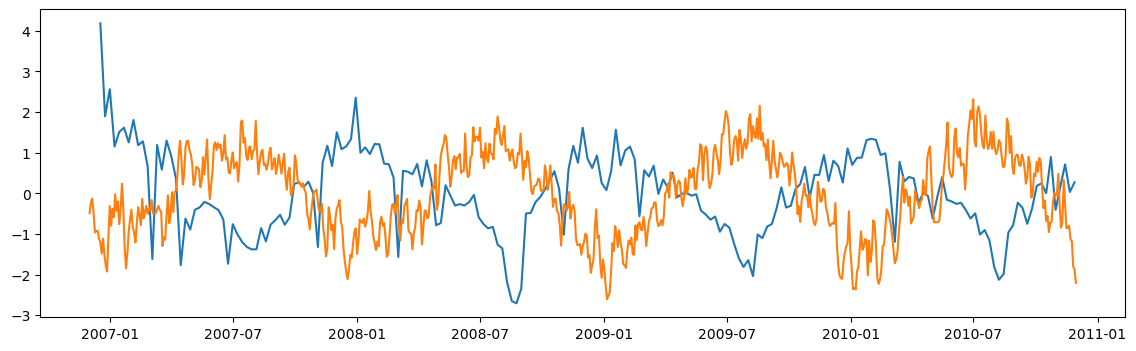

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
print(len(ihepc_weekly), len(weather_daily))
plt.plot(power_weekly)
plt.plot(weather_daily)
plt.show()

In [5]:
Bx = power_weekly.index.view("int64").reshape(-1, 1).astype(float)
By = power_weekly.values.reshape(-1, 1).astype(np.float64)
Ax = weather_daily.index.view("int64").reshape(-1, 1).astype(float)
Ay = weather_daily.values.reshape(-1, 1).astype(np.float64)
n_test = 12
Xtest, ytest = Bx[-n_test:], By[-n_test:]
print(Bx.shape, By.shape)
Bx, By = Bx[:-n_test,:], By[:-n_test,:]
print(Bx.shape, By.shape)
print(len(Xtest), len(ytest))
Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
print(Ax.shape, Ay.shape, Bx.shape, By.shape)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax, dtype=np.int32))), np.hstack((Bx, np.ones_like(Bx, dtype=np.int32)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay, dtype=np.int32))), np.hstack((By, np.ones_like(By, dtype=np.int32)))))
Xtest = np.hstack((Xtest, np.ones_like(Xtest)))


(207, 1) (207, 1)
(195, 1) (195, 1)
12 12
(731, 1) (731, 1) (195, 1) (195, 1)


### CMOGP, takes about 1 minute with 20 ivs (100 is already much better, that takes 5 minutes or so) 

tf.Tensor(-357.53265147461235, shape=(), dtype=float64)
╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].base_kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].base_kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────────────┼───────────┼──────────

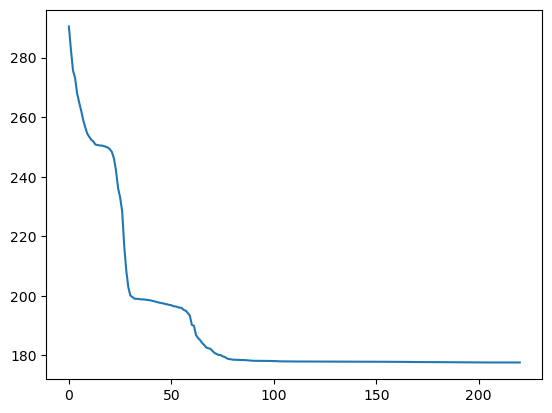

╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════════════╡
│ SparseCMOGP.kernel.kernels[0].base_kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.18717              │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────────────┤
│ SparseCMOGP.kernel.kernels[0].base_kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.5228517456825137   │
├────────────────────────────────────────────────────────┼

In [6]:
output_dim = 2 # Number of outputs
#k = gpf.kernels.RBF()
k2 = gpf.kernels.Periodic(gpf.kernels.Matern12())
# Base kernel

# Coregion kernel
coreg1 = gpf.kernels.Coregion(output_dim=output_dim, rank=1, active_dims=[1])
ivs = np.linspace(0, max(Xtest[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k2 * coreg1
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-4, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

print(m.maximum_log_likelihood_objective())

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)


tf.Tensor(
[[0.49556775]
 [0.5310623 ]
 [0.55560821]
 [0.56934582]
 [0.57235397]
 [0.56465016]
 [0.54619056]
 [0.51686994]
 [0.47652156]
 [0.42491789]
 [0.36198718]
 [0.28712503]], shape=(12, 1), dtype=float64)


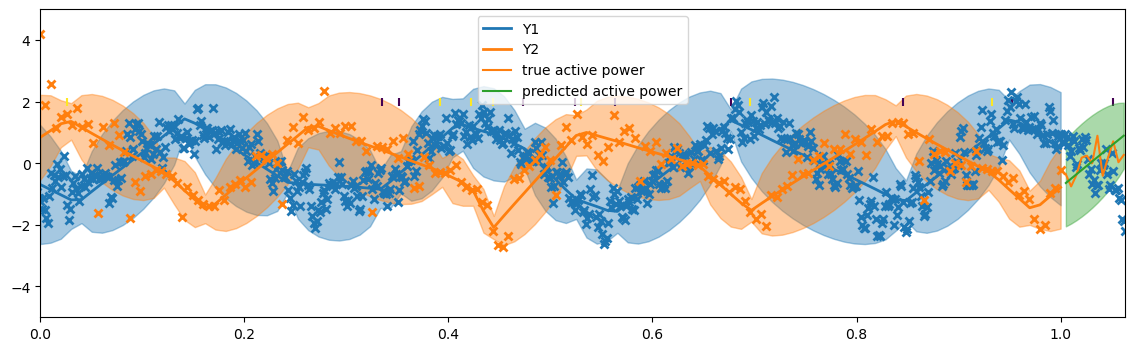

0.20538191735675207


In [7]:
plot(m)
mu, var = m.predict_f(Xtest)
print(var)
plt.plot(Xtest[:,0], ytest, color="C1", label="true active power")
plt.plot(Xtest[:,0], mu, color="C2", label="predicted active power")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


### Comparison to VGP (takes 10 minutes on my machine)

In [8]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Periodic(gpf.kernels.Matern12())


# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
# now build the GP model as normal
m = gpf.models.VGP((X, y), kernel=kern, likelihood=lik)#, num_data=len(X), inducing_variable=ivs)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 673.967193068497
        x: [-6.328e-01 -1.377e-01 ... -1.804e+00 -1.093e+00]
      nit: 4303
      jac: [ 3.930e-01  2.598e-02 ...  3.181e-02  3.803e-02]
     nfev: 5198
     njev: 5198
 hess_inv: <430136x430136 LbfgsInvHessProduct with dtype=float64>

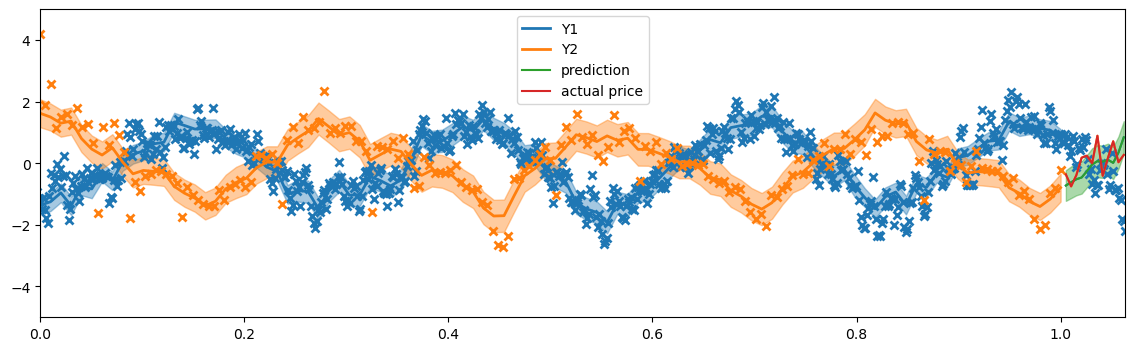

0.22032811751048745


In [9]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))